# PREPROCESSING JOB

This notebook is running on a local server. However, this local notebook environment does not have enough computing power to process massive flight delay data.

To solve this, we are going to make SageMaker "rent a powerful virtual computer (ml.m5.large) in the AWS cloud to do the heavy lifting"

In [2]:
import boto3, os
from sagemaker.core.helper.session_helper import Session, get_execution_role

sess = Session()
bucket = sess.default_bucket()
role = get_execution_role()
region = sess.boto_region_name

s3 = boto3.client("s3")


sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml


sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml


In [3]:

os.makedirs("/tmp/test_input/year=2024/month=01", exist_ok=True)

s3.download_file(
  bucket,
  "airline-delay/raw/year=2024/month=01/flights.csv",
  "/tmp/test_input/year=2024/month=01/flights.csv"
)
print("Downloaded ✓")


Downloaded ✓


In [4]:
%store -r s3_aerodelay

In [5]:
%store

Stored variables and their in-db values:
aerodelay_db                         -> 'aerodelay'
aerodelay_s3_staging_dir             -> 's3://sagemaker-us-east-1-103012382341/athena/stag
aerodelay_table                      -> 'flights'
s3_aerodelay                         -> 's3://sagemaker-us-east-1-103012382341/airline-del


In [6]:
# 1. Import the utility from sagemaker.core
from sagemaker.core.image_uris import retrieve
from sagemaker.core.helper.session_helper import Session

# 2. Retrieve dynamically using the native framework key 'sklearn'
image_string = retrieve(
    framework="sklearn",   # Note: 'sklearn' replaces the legacy 'scikit-learn' key
    region=region,
    version="1.2-1"
)

print(f"Official Image String: {image_string}")


[05/31/26 21:54:39] INFO     Defaulting to only available Python version: py3                     ]8;id=2532569;file:///opt/conda/lib/python3.12/site-packages/sagemaker/core/image_uris.py\image_uris.py]8;;\:]8;id=2532570;file:///opt/conda/lib/python3.12/site-packages/sagemaker/core/image_uris.py#615\615]8;;\

                    INFO     Defaulting to only supported image scope: cpu.                       ]8;id=2532576;file:///opt/conda/lib/python3.12/site-packages/sagemaker/core/image_uris.py\image_uris.py]8;;\:]8;id=2532577;file:///opt/conda/lib/python3.12/site-packages/sagemaker/core/image_uris.py#539\539]8;;\

Official Image String: 683313688378.dkr.ecr.us-east-1.amazonaws.com/sagemaker-scikit-learn:1.2-1-cpu-py3


In [8]:
import os
print(f"Active location: {os.getcwd()}")


Active location: /home/sagemaker-user/Airline-Delay-Prediction-with-AWS-SageMaker


In [9]:
import sagemaker
from sagemaker.core.image_uris import retrieve
from sagemaker.core.processing import ScriptProcessor
from sagemaker.core.shapes import (
    ProcessingInput, 
    ProcessingS3Input, 
    ProcessingOutput, 
    ProcessingS3Output
)

processor = ScriptProcessor(
    command=['python3'],
    image_uri=image_string,
    role=role,
    instance_count=1,
    instance_type='ml.m5.large',
    sagemaker_session=sess
)

print("Submitting validated V3 payload to AWS...")

processor.run(
  code="preprocessing/preprocess.py",
  inputs=[
      ProcessingInput(
          input_name="aerodelay_raw_input",
          s3_input=ProcessingS3Input(
              s3_uri=f"{s3_aerodelay}/raw/",
              local_path="/opt/ml/processing/input",
              s3_data_type="S3Prefix",
              s3_input_mode="File"
          )
      )
  ],
  outputs=[
      ProcessingOutput(
          output_name="train_data",
          s3_output=ProcessingS3Output(
              local_path="/opt/ml/processing/output/train",
              s3_uri=f"{s3_aerodelay}/training/",
              s3_upload_mode="EndOfJob"
          )
      ),
      ProcessingOutput(
          output_name="validation_data",
          s3_output=ProcessingS3Output(
              local_path="/opt/ml/processing/output/validation",
              s3_uri=f"{s3_aerodelay}/validation/",
              s3_upload_mode="EndOfJob"
          )
      ),
      ProcessingOutput(
          output_name="test_data",
          s3_output=ProcessingS3Output(
              local_path="/opt/ml/processing/output/test",
              s3_uri=f"{s3_aerodelay}/test/",
              s3_upload_mode="EndOfJob"
          )
      ),
      ProcessingOutput(
          output_name="production_simulation_data",
          s3_output=ProcessingS3Output(
              local_path="/opt/ml/processing/output/production_simulation",
              s3_uri=f"{s3_aerodelay}/production_simulation/",
              s3_upload_mode="EndOfJob"
          )
      )
  ]
)

print(f"Processing Job Successfully Created")

╭──────────────────────────────────────────────── Wait Log Panel ─────────────────────────────────────────────────╮
│ [=== ] Waiting for ProcessingJob... 0:05:04                                                                     │
│ ⠧ Current status: InProgress                                                                                    │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

[05/31/26 22:00:58] INFO     Final Resource Status: Completed                                    ]8;id=2532712;file:///opt/conda/lib/python3.12/site-packages/sagemaker/core/resources.py\resources.py]8;;\:]8;id=2532713;file:///opt/conda/lib/python3.12/site-packages/sagemaker/core/resources.py#28439\28439]8;;\

Processing Job Successfully Created


# Test the Processed Data

In [10]:
for split in ["training", "validation", "test", "production_simulation"]:
  resp = s3.list_objects_v2(Bucket=bucket, Prefix=f"airline-delay/{split}/")
  files = [o["Key"] for o in resp.get("Contents", [])]
  print(f"{split}: {files}")

training: ['airline-delay/training/data.parquet']
validation: ['airline-delay/validation/data.parquet']
test: ['airline-delay/test/data.parquet']
production_simulation: ['airline-delay/production_simulation/data.parquet']


# Processinng Job Architecture

When processor.run() executes, SageMaker decouples the notebook interface from the actual data processing workload. The orchestration flows through five automated stages:
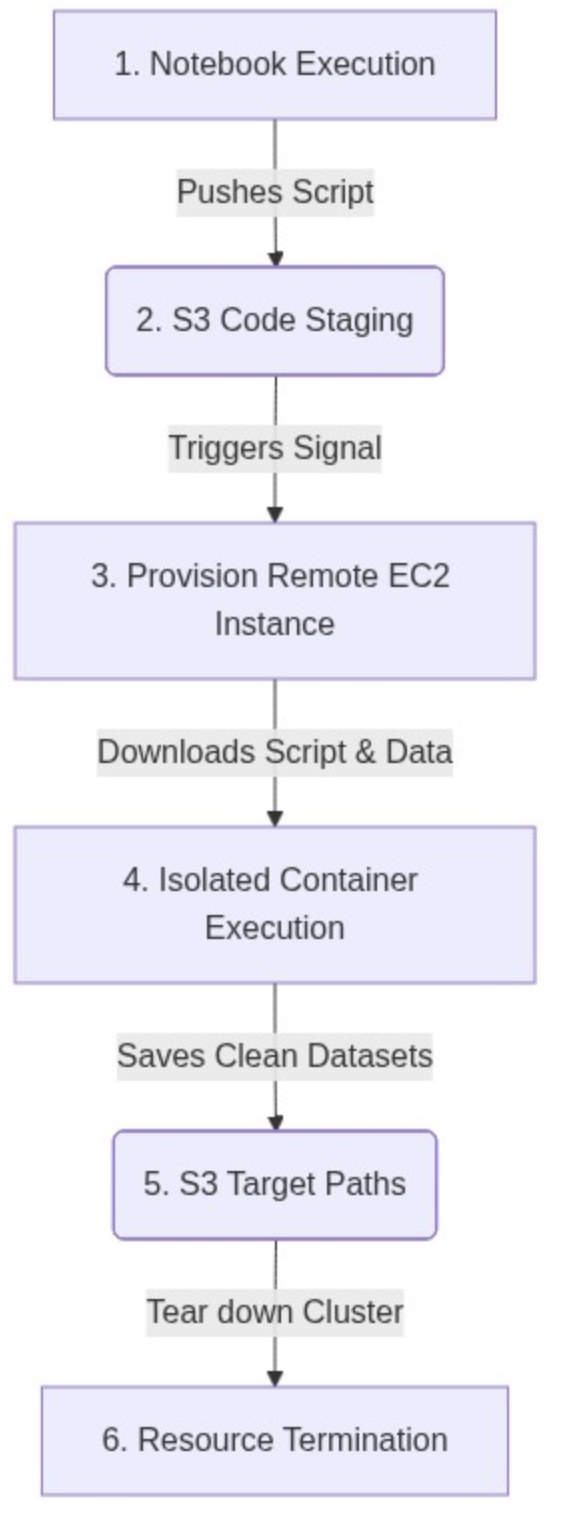

**1. Code Staging (The S3 Upload)**

Because the target processing cluster (single-node cluster, only 1 instance) cannot access the local notebook disk partition, the SDK reads the local preprocess.py script. It automatically uploads a copy to a uniquely generated folder inside the regional default Amazon S3 bucket:

Target Schema Path: s3://sagemaker-[region]-[account-id]/[job-name]/input/code/preprocess.py [05/31/26 19:30:40]

**2. Infrastructure Provisioning**

SageMaker acts on the hardware allocation parameters defined in the processor config (instance_type='ml.m5.large', instance_count=1). AWS instantly provisions an isolated virtual machine inside the secure cloud data center.

**3. Provision remote EC2 instance**

The newly booted cloud instance initialises its runtime environment:

- It pulls down the official AWS-managed Scikit-Learn ECR container image
- It downloads the staged preprocess.py file from S3 into its internal container memory
- It syncs the raw source dataset from project raw folder ({s3_aerodelay}/raw/) and mounts it locally inside the instance path at /opt/ml/processing/input.

**4. Script Execution**

The remote cluster executes the Python script (python3 preprocess.py). The dataset is parsed out of the local input mount, modified via Scikit-Learn logic (handling missing fields, mapping features), and written out into the local container directory (/opt/ml/processing/output/).

**5. S3 Synchronization & Auto-Termination**

Once the script concludes successfully, the infrastructure uploads the clean datasets back into our persistent project S3 paths ( {s3_aerodelay}/training/, /validation/, /test/, and /production_simulation/ ). As soon as the upload completes, AWS automatically terminates the virtual machine cluster so you only pay for the exact minutes used.


In [17]:
import base64
from IPython.display import Image, display

def mm(graph):
    graph_bytes = graph.encode("utf8")
    base64_bytes = base64.urlsafe_b64encode(graph_bytes)
    base64_string = base64_bytes.decode("ascii")
    display(Image(url="https://mermaid.ink/img/" + base64_string))
mm("""graph TD
    A[1. Notebook Execution] -->|Pushes Script| B(2. S3 Code Staging)
    B -->|Triggers Signal| C[3. Provision Remote EC2 Instance]
    C -->|Downloads Script & Data| D[4. Isolated Container Execution]
    D -->|Saves Clean Datasets| E(5. S3 Target Paths)
    E -->|Tear down Cluster| F[6. Resource Termination]""")